# ⚾ 타자 맞춤 점검: 회피는 그 타자를 향한 것인가, 그 구종 자체를 덜 쓰게 된 것인가?

* **작성자:** CY
* **작성일:** 2026-10-05
* **배경:** 재대결 순수 감소(약 14%p)가 다음 타자(약 7%p)보다 커서 "장타를 친 그 타자에게 맞춰 피한다"고 읽고 싶어집니다. 하지만 두 표본은 모집단이 다릅니다. 재대결은 타순이 한 바퀴 돌 때까지 던진 투수(주로 선발)이고, 다음 타자는 2아웃 장타가 빠지고 다음 타석에 주자가 많습니다. 그래서 두 숫자를 비교해서는 타자 맞춤인지 알 수 없습니다.
* **설계:** **같은 장타 이벤트 안에서** 비교합니다. 장타 뒤 재대결 전까지 상대한 **중간 타자들**과 **재대결 타석**에서 T를 얼마나 피했는지를 나란히 봅니다. 같은 투수, 같은 경기, 같은 장타라 모집단 차이가 없습니다.
  * **회피(타석별)** = 그 손(좌/우) 타자 상대 시즌 T 구사율 − 그 타석의 T 비율. 중간 타자들은 장타 친 타자와 좌우가 다를 수 있어 손별 구사율을 기준으로 씁니다.
  * **타자 맞춤 회피** = 재대결 회피 − 중간 타자 회피(투구 수 가중). 양수면 그 타자에게 더 피한 것입니다.
  * **대조군:** 재대결은 원래 다음 타순 회차라 배합이 바뀌므로, M3로 매칭한 `field_out` 이벤트에도 같은 값을 구해 뺍니다.
* **읽는 법:** 장타군의 타자 맞춤 회피가 대조군보다 크면 → 그 타자를 향한 회피. 차이가 없고 중간 타자에게도 비슷하게 피하면 → 그 구종을 덜 쓰게 된 것.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

from src.analysis.avoidance_stats import compute_season_usage_rate
from src.analysis.batter_specific import (
    event_summary, hand_season_usage, pa_avoidance, pa_table, prior_same_batter_avoidance,
)
from src.analysis.situation_matching import add_situation_columns, build_step, build_xbh_events
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
OUT_DIR = '../data/processed'
FIG_DIR = '../data/processed/figures'
os.makedirs(FIG_DIR, exist_ok=True)
GROUP_LABELS = {1: '장타', 0: '대조군(field_out)'}

## 1. 데이터와 이벤트 (재대결, M3 매칭)

In [2]:
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'player_name', 'batter',
    'stand', 'p_throws', 'pitch_type', 'events', 'balls', 'strikes', 'outs_when_up',
    'inning', 'inning_topbot', 'on_1b', 'on_2b', 'on_3b', 'home_score', 'away_score',
]
frames = [pd.read_csv(p, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False) for p in list_research_csvs()]
pitches = pd.concat(frames, ignore_index=True)
pitches['season'] = pd.to_datetime(pitches['game_date']).dt.year
assert len(pitches) == 3_592_302 and not pitches.duplicated(KEY_COLUMNS).any()
pitches = add_situation_columns(pitches)
season_usage = compute_season_usage_rate(pitches)

xbh = build_xbh_events(pitches, season_usage, 'same_batter')
xbh_m, placebo = build_step('M3', pitches, xbh, season_usage, 'same_batter')
events = pd.concat([xbh_m.assign(group=1), placebo.assign(group=0)], ignore_index=True)
events = events[events['has_next_ab'] & events['hit_pitch_type'].notna()].reset_index(drop=True)
events['event_id'] = np.arange(len(events))
print(events.groupby('group').size().rename(GROUP_LABELS))

group
대조군(field_out)    26816
장타                26816
dtype: int64


## 2. 타석별 회피 계산

In [3]:
pas, by_type = pa_table(pitches)
hand = hand_season_usage(pitches)
pa = pa_avoidance(events, pas, by_type, hand).merge(events[['event_id', 'group', 'pitcher', 'events']], on=['event_id', 'pitcher'])
summary = event_summary(pa).merge(events[['event_id', 'group', 'pitcher', 'events', 'pitch_family']], on='event_id')

n_inter = pa[pa['role'] == 'intervening'].groupby('event_id').size()
print('중간 타석 수 분포:', n_inter.describe()[['mean', '50%', 'min', 'max']].round(1).to_dict())
print('사용 이벤트:', summary.groupby('group').size().rename(GROUP_LABELS).to_dict())
assert (pa.groupby('event_id')['role'].apply(lambda r: (r == 'rematch').sum()) == 1).all(), '재대결 타석이 이벤트마다 1개가 아님'

중간 타석 수 분포: {'mean': 8.0, '50%': 8.0, 'min': 8.0, 'max': 10.0}
사용 이벤트: {'대조군(field_out)': 26816, '장타': 26816}


## 3. 결과: 중간 타자 vs 재대결

* `avoid_inter`, `avoid_rematch`: 손별 시즌 구사율 대비 T를 얼마나 덜 던졌나 (양수 = 덜 던짐)
* `batter_specific` = `avoid_rematch − avoid_inter`
* 장타 − 대조군 차이와 95% CI는 **투수 단위 cluster 표준오차**(OLS)로 계산합니다. 같은 투수의 이벤트가 여러 번 들어가는 점을 반영합니다.

In [4]:
def group_diff(df, col):
    fit = smf.ols(f'{col} ~ group', data=df).fit(cov_type='cluster', cov_kwds={'groups': df['pitcher']})
    lo, hi = fit.conf_int().loc['group']
    return {'xbh': df.loc[df['group'] == 1, col].mean(), 'control': df.loc[df['group'] == 0, col].mean(),
            'diff': fit.params['group'], 'ci_low': lo, 'ci_high': hi, 'p': fit.pvalues['group']}


result = pd.DataFrame({c: group_diff(summary, c) for c in ['avoid_inter', 'avoid_rematch', 'batter_specific']}).T
display((result * [100, 100, 100, 100, 100, 1]).round(3).rename(columns={'p': 'p'}))
result.to_csv(f'{OUT_DIR}/batter_specific_summary.csv')

,xbh,control,diff,ci_low,ci_high,p
avoid_inter,2.468,-1.566,4.034,3.843,4.225,0.0
avoid_rematch,12.466,-1.067,13.533,13.026,14.039,0.0
batter_specific,9.998,0.499,9.499,9.004,9.994,0.0


## 4. 장타 뒤 타석 순서별 회피

중간 타자 k번째(k = 1은 장타 직후 다음 타자)와 재대결 타석의 회피를 장타 − 대조군으로 봅니다. 장타 뒤 시간이 지나며 회피가 줄다가 **재대결에서 다시 커지면** 타자 맞춤 회피입니다.

In [5]:
pa['slot'] = np.where(pa['role'] == 'rematch', '재대결', pa['k'].clip(upper=9).astype(str))
slot_order = [str(k) for k in range(1, 10)] + ['재대결']
# 타석별 회피를 이벤트 안에서 평균 → 집단 평균
by_slot = pa.groupby(['slot', 'group'])['avoid'].agg(['mean', 'std', 'size']).unstack('group')
rows = []
for s in slot_order:
    if s not in by_slot.index:
        continue
    m1, m0 = by_slot.loc[s, ('mean', 1)], by_slot.loc[s, ('mean', 0)]
    se = np.sqrt(by_slot.loc[s, ('std', 1)] ** 2 / by_slot.loc[s, ('size', 1)] + by_slot.loc[s, ('std', 0)] ** 2 / by_slot.loc[s, ('size', 0)])
    rows.append({'slot': s, 'n_xbh': int(by_slot.loc[s, ('size', 1)]), 'xbh': m1, 'control': m0, 'net': m1 - m0,
                 'ci_low': m1 - m0 - 1.96 * se, 'ci_high': m1 - m0 + 1.96 * se})
slots = pd.DataFrame(rows)
display(slots.assign(**{c: slots[c] * 100 for c in ['xbh', 'control', 'net', 'ci_low', 'ci_high']}).round(2))
slots.to_csv(f'{OUT_DIR}/batter_specific_by_slot.csv', index=False)
print('9 = 9번째 이후 중간 타석을 합친 값. 순서별 CI는 독립 가정(참고용)')

,slot,n_xbh,xbh,control,net,ci_low,ci_high
0,1,26816,4.93,-1.94,6.87,6.44,7.30
1,2,26816,3.02,-2.50,5.51,5.07,5.96
2,3,26816,1.89,-1.96,3.86,3.41,4.31
3,4,26816,1.71,-1.71,3.42,2.97,3.88
4,5,26816,1.86,-1.97,3.83,3.37,4.29
5,6,26816,2.24,-1.42,3.66,3.20,4.12
6,7,26816,2.28,-1.08,3.36,2.90,3.82
7,8,26816,1.88,-1.10,2.99,2.53,3.44
8,9,439,2.65,-2.72,5.37,1.76,8.98
9,재대결,26816,12.47,-1.07,13.53,13.09,13.97


9 = 9번째 이후 중간 타석을 합친 값. 순서별 CI는 독립 가정(참고용)


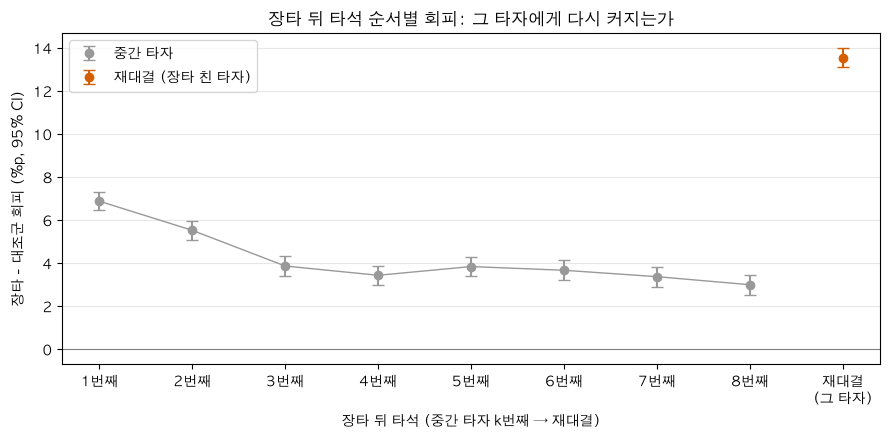

In [6]:
plot = slots[slots['slot'] != '9'].reset_index(drop=True)  # 9번째 이후는 439건뿐이라 그림에서 제외
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(plot))
y = plot['net'] * 100
err = np.vstack([y - plot['ci_low'] * 100, plot['ci_high'] * 100 - y])
ax.errorbar(x[:-1], y[:-1], yerr=err[:, :-1], fmt='o', capsize=4, color='#999999', label='중간 타자')
ax.errorbar(x[-1:], y[-1:], yerr=err[:, -1:], fmt='o', capsize=4, color='#D55E00', label='재대결 (장타 친 타자)')
ax.legend()
ax.plot(x[:-1], y[:-1], color='#999999', lw=1)
ax.set_xticks(x, [f'{s}번째' if s != '재대결' else '재대결\n(그 타자)' for s in plot['slot']])
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('장타 뒤 타석 (중간 타자 k번째 → 재대결)')
ax.set_ylabel('장타 - 대조군 회피 (%p, 95% CI)')
ax.set_title('장타 뒤 타석 순서별 회피: 그 타자에게 다시 커지는가')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/batter_specific_by_slot.png', dpi=150)
plt.show()

## 5. 나눠 보기: 홈런 vs 2·3루타, 구종계열

In [7]:
summary['xbh_type'] = summary['events'].map({'home_run': '홈런', 'double': '2·3루타', 'triple': '2·3루타'})
rows = []
for label, sub in [('홈런', summary[(summary['group'] == 0) | (summary['xbh_type'] == '홈런')]),
                   ('2·3루타', summary[(summary['group'] == 0) | (summary['xbh_type'] == '2·3루타')])]:
    rows.append({'split': label, **group_diff(sub, 'batter_specific')})
for fam in ['fastball', 'breaking', 'offspeed']:
    rows.append({'split': fam, **group_diff(summary[summary['pitch_family'] == fam], 'batter_specific')})
splits = pd.DataFrame(rows).set_index('split')
display((splits[['xbh', 'control', 'diff', 'ci_low', 'ci_high']] * 100).round(2).join(splits['p'].round(4)))
splits.to_csv(f'{OUT_DIR}/batter_specific_splits.csv')
print('홈런/2·3루타 행의 대조군은 전체 대조군(장타 종류로 매칭하지 않음)')

,xbh,control,diff,ci_low,ci_high,p
split,,,,,,
홈런,11.97,0.50,11.47,10.86,12.07,0.0
2·3루타,8.70,0.50,8.20,7.65,8.75,0.0
fastball,9.60,0.81,8.79,8.15,9.42,0.0
breaking,10.80,0.15,10.64,9.80,11.49,0.0
offspeed,10.28,-0.28,10.57,9.47,11.66,0.0


홈런/2·3루타 행의 대조군은 전체 대조군(장타 종류로 매칭하지 않음)


## 6. 대안 설명 확인: 원래 그 타자에게 T를 피하고 있었나?

장타를 친 타자는 평균보다 강한 타자일 수 있고, 투수가 그런 타자에게는 처음부터 T를 덜 던졌을 수 있습니다. 그렇다면 재대결 회피는 장타에 대한 반응이 아닙니다.
장타 **이전**에 같은 경기에서 같은 타자를 상대한 타석(있는 이벤트만)의 회피를 봅니다. 장타군과 대조군 모두 이 이벤트들로 한정해 재대결 회피와 나란히 비교합니다.

In [8]:
prior = prior_same_batter_avoidance(events, pas, by_type, hand)
both = summary.merge(prior, on='event_id')
print('장타 이전 같은 타자 타석이 있는 이벤트:', both.groupby('group').size().rename(GROUP_LABELS).to_dict())
prior_res = pd.DataFrame({c: group_diff(both, c) for c in ['avoid_prior', 'avoid_inter', 'avoid_rematch']}).T
display((prior_res * [100, 100, 100, 100, 100, 1]).round(3))
prior_res.to_csv(f'{OUT_DIR}/batter_specific_prior.csv')

장타 이전 같은 타자 타석이 있는 이벤트: {'대조군(field_out)': 9297, '장타': 9230}


,xbh,control,diff,ci_low,ci_high,p
avoid_prior,-5.705,-4.203,-1.502,-2.268,-0.736,0.0
avoid_inter,2.557,-1.352,3.909,3.590,4.228,0.0
avoid_rematch,12.447,-1.409,13.856,13.082,14.630,0.0


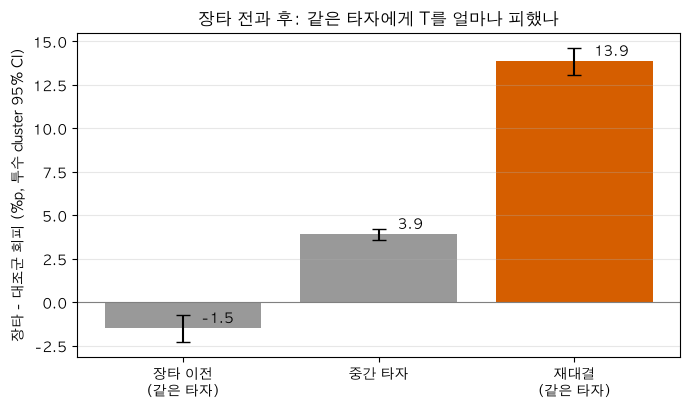

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.2))
labels = ['장타 이전\n(같은 타자)', '중간 타자', '재대결\n(같은 타자)']
y = prior_res['diff'] * 100
ax.bar(range(3), y, color=['#999999', '#999999', '#D55E00'],
       yerr=[y - prior_res['ci_low'] * 100, prior_res['ci_high'] * 100 - y], capsize=5)
for i, v in enumerate(y):
    ax.annotate(f'{v:.1f}', (i, v), textcoords='offset points', xytext=(14, 4), ha='left')
ax.set_xticks(range(3), labels)
ax.axhline(0, color='grey', lw=0.8)
ax.set_ylabel('장타 - 대조군 회피 (%p, 투수 cluster 95% CI)')
ax.set_title('장타 전과 후: 같은 타자에게 T를 얼마나 피했나')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/batter_specific_prior.png', dpi=150)
plt.show()

## 7. 해석

* **표본.** 재대결 장타 26,816건과 M3로 매칭한 `field_out` 26,816건. 장타와 재대결 사이에는 거의 항상 중간 타자 8명이 있습니다(타순 한 바퀴).
* **결론: 회피는 그 타자를 향합니다.** 같은 장타 이벤트 안에서, 대조군보다 더 피한 정도가 중간 타자에게는 **4.0%p** [3.8, 4.2]인데 재대결(장타 친 타자)에게는 **13.5%p** [13.0, 14.0]입니다. 그 차이인 타자 맞춤 회피는 **9.5%p** [9.0, 10.0]입니다(투수 단위 cluster 95% CI). 같은 투수·경기·장타 안의 비교라, 재대결과 다음 타자 분석의 모집단 차이로는 설명되지 않습니다.
* **시간이 지나며 줄다가 그 타자에게 다시 커집니다.** 장타 직후 다음 타자에게 6.9%p, 두 번째 5.5%p, 세 번째부터 여덟 번째까지 3.0~3.8%p로 줄어듭니다. 그런데 장타를 친 타자가 다시 나오면 13.5%p로 뛰어오릅니다. 장타 직후의 회피는 일부가 그 구종 전반에 대한 일시적 회피이고, 대부분은 그 타자를 향한 것입니다.
* **원래 그 타자에게 피하던 것이 아닙니다.** 장타 이전에 같은 타자를 상대한 타석이 있는 이벤트(장타 9,230 / 대조군 9,297건)에서, 장타 **이전**의 회피는 대조군보다 오히려 **−1.5%p** [−2.3, −0.7]입니다. 즉 그 타자에게 T를 평소보다 더 던지고 있었습니다. 장타 뒤 재대결에서 13.9%p로 바뀝니다. "강타자라 처음부터 피했다"는 설명은 맞지 않고, 장타가 기점입니다.
* **장타 종류·구종과 무관하게 남습니다.** 타자 맞춤 회피(대조군 대비)는 홈런 11.5%p, 2·3루타 8.2%p, 패스트볼 8.8, 브레이킹 10.6, 오프스피드 10.6%p로 모두 뚜렷합니다. 홈런 뒤에 더 큽니다.
* **보고서 주장에 주는 의미.** "장타를 맞은 구종을 덜 쓰게 된다"는 효과(중간 타자 약 3~4%p)도 있지만, 재대결 회피의 약 70%(9.5/13.5)는 **장타를 친 그 타자에게 맞춘 회피**입니다.
* **한계.**
  * 회피 기준을 손별 시즌 구사율로 잡아, 타순 회차에 따른 배합 변화는 대조군 차이로만 걷어냈습니다.
  * 장타 이전 확인은 같은 경기에서 그 타자를 장타 전에 상대한 이벤트(약 3분의 1)로만 가능합니다.
  * 그날 그 구종의 상태는 아직 통제하지 않았습니다(구종 상태 점검, 노트북 07). 다만 "구종 상태가 나빠서"라면 중간 타자에게도 비슷하게 피해야 하는데, 회피가 그 타자에게 집중된다는 점은 이 설명만으로는 맞지 않습니다.
  * 타석 순서별 CI는 독립 가정(참고용)입니다. 집단 비교(3·5·6절)는 투수 cluster CI입니다.